In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
customers   = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\olist_customers_dataset.csv\olist_customers_dataset.csv")
geolocation = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\olist_geolocation_dataset.csv\olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\olist_order_items_dataset.csv\olist_order_items_dataset.csv")
payments    = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\olist_order_payments_dataset.csv\olist_order_payments_dataset.csv")
reviews     = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\olist_order_reviews_dataset.csv\olist_order_reviews_dataset.csv")
orders      = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\olist_orders_dataset.csv\olist_orders_dataset.csv")
products    = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\olist_products_dataset.csv\olist_products_dataset.csv")
sellers     = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\olist_sellers_dataset.csv")
category_translation = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\product_category_name_translation.csv")

print("All files loaded")

All files loaded


In [4]:
print("customers:", customers.shape)
print("order_items:", order_items.shape)
print("payments:", payments.shape)
print("reviews:", reviews.shape)
print("orders:", orders.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("category_translation:", category_translation.shape)

customers: (99441, 5)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (71, 2)


## Step 2: Look at the data types and missing values  
We check one table at a time so it's easy to read.

In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [8]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [9]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [10]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

## Step 3: Convert date columns to real dates
Right now, date columns are just text (object type). We convert them using `pd.to_datetime()`.

In [11]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Check it worked
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [12]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

reviews.dtypes

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

## Step 4: Check for duplicate rows

In [13]:
print("Duplicate rows in orders:", orders.duplicated().sum())
print("Duplicate rows in customers:", customers.duplicated().sum())
print("Duplicate rows in products:", products.duplicated().sum())
print("Duplicate rows in reviews:", reviews.duplicated().sum())

Duplicate rows in orders: 0
Duplicate rows in customers: 0
Duplicate rows in products: 0
Duplicate rows in reviews: 0


In [14]:
# Check if any order_id appears more than once (it shouldn't, since order_id is a unique key)
print("Repeated order_id in orders table:", orders['order_id'].duplicated().sum())

Repeated order_id in orders table: 0


## Step 5: Fix missing product categories
Some products don't have a category name. We'll just label them as "unknown" instead of deleting them.

In [15]:
print("Missing categories before fix:", products['product_category_name'].isnull().sum())

products['product_category_name'] = products['product_category_name'].fillna('unknown')

print("Missing categories after fix:", products['product_category_name'].isnull().sum())

Missing categories before fix: 610
Missing categories after fix: 0


In [16]:
# Translate category names from Portuguese to English
products = products.merge(category_translation, on='product_category_name', how='left')

# Some categories might not have a translation - fill those with the original name
products['product_category_name_english'] = products['product_category_name_english'].fillna(products['product_category_name'])

products[['product_category_name', 'product_category_name_english']].head()

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares


## Step 6: Look for outliers in price
We just look at the basic statistics first (min, max, average) to spot anything strange, like a price of 0 or a huge price.

In [17]:
order_items['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [18]:
# Check for prices that are 0 or negative (these would be data errors)
zero_price_count = (order_items['price'] <= 0).sum()
print("Number of items with price 0 or less:", zero_price_count)

Number of items with price 0 or less: 0


In [19]:
# Look at the 10 most expensive items, just to sanity check they make sense
order_items.sort_values('price', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34
62086,8dbc85d1447242f3b127dda390d56e19,1,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,2018-06-28 12:36:36,4590.00,91.78
29193,426a9742b533fc6fed17d1fd6d143d7e,1,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,2018-08-16 14:24:28,4399.87,113.45
45843,68101694e5c5dc7330c91e1bbc36214f,1,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,2018-04-05 08:27:27,4099.99,75.27
78310,b239ca7cd485940b31882363b52e6674,1,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,2018-08-02 08:15:14,4059.00,104.51
59137,86c4eab1571921a6a6e248ed312f5a5a,1,6902c1962dd19d540807d0ab8fade5c6,fa1c13f2614d7b5c4749cbc52fecda94,2017-03-23 20:08:04,3999.90,17.01


## Step 7: Combine (merge) all the tables into one
We join everything using `order_id`, `product_id`, `customer_id`, and `seller_id` so we have one row per ordered item, with all the details attached.

In [20]:
# Step-by-step merging - one merge at a time, so it's easy to follow

# Start with order_items, and attach order info
df = order_items.merge(orders, on='order_id', how='left')
print("After joining orders:", df.shape)

After joining orders: (112650, 14)


In [21]:
# Attach customer info
df = df.merge(customers, on='customer_id', how='left')
print("After joining customers:", df.shape)

After joining customers: (112650, 18)


In [22]:
# Attach product info (just the columns we need)
df = df.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
print("After joining products:", df.shape)

After joining products: (112650, 19)


In [23]:
# Attach seller info
df = df.merge(sellers, on='seller_id', how='left')
print("After joining sellers:", df.shape)

After joining sellers: (112650, 22)


In [24]:
# Attach review score (some orders may have more than one review row, so we keep the first one per order)
reviews_simple = reviews.drop_duplicates(subset='order_id', keep='first')
df = df.merge(reviews_simple[['order_id', 'review_score']], on='order_id', how='left')
print("After joining reviews:", df.shape)

After joining reviews: (112650, 23)


In [25]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,27277,volta redonda,SP,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,3471,sao paulo,SP,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,furniture_decor,37564,borda da mata,MG,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumery,14403,franca,SP,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,garden_tools,87900,loanda,PR,5.0


## Step 8: Create a few useful new columns
These will help us answer questions later, like "did the order arrive late?".

In [26]:
# Was the order delivered late? (actual delivery date later than estimated date)
df['is_late_delivery'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

df['is_late_delivery'].value_counts()

is_late_delivery
False    103935
True       8715
Name: count, dtype: int64

In [27]:
# How many days late (or early) was the delivery?
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

df['delivery_delay_days'].describe()

count    110196.000000
mean        -12.030201
std          10.160157
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay_days, dtype: float64

In [28]:
# Freight ratio = shipping cost divided by product price
# (a high number means shipping cost a lot compared to the product itself)
df['freight_ratio'] = df['freight_value'] / df['price']

df['freight_ratio'].describe()

count    112650.000000
mean          0.320864
std           0.349894
min           0.000000
25%           0.134034
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

## Step 9: Save the final cleaned dataset

In [29]:
df.to_csv('olist_clean_dataset.csv', index=False)
print("Saved as olist_clean_dataset.csv")
print("Final size:", df.shape)

Saved as olist_clean_dataset.csv
Final size: (112650, 26)


---
### What we did
- Loaded 8 CSV files
- Checked for missing values and duplicates
- Fixed date columns and missing categories
- Combined everything into one table (`df`)
- Added 3 new columns: `is_late_delivery`, `delivery_delay_days`, `freight_ratio`

### Next step
Use `olist_clean_dataset.csv` for your SQL analysis and charts (Phase 3 and Phase 5 of your project plan).
Run this notebook top to bottom and tell me what you see — especially any error messages or numbers that look odd.

In [31]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,customer_city,customer_state,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,review_score,is_late_delivery,delivery_delay_days,freight_ratio
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,campos dos goytacazes,RJ,cool_stuff,27277,volta redonda,SP,5.0,False,-9.0,0.225637
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,santa fe do sul,SP,pet_shop,3471,sao paulo,SP,4.0,False,-3.0,0.083076
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,para de minas,MG,furniture_decor,37564,borda da mata,MG,5.0,False,-14.0,0.089799
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,atibaia,SP,perfumery,14403,franca,SP,4.0,False,-6.0,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,varzea paulista,SP,garden_tools,87900,loanda,PR,5.0,False,-16.0,0.090745


In [34]:
# Make sure the date columns are proper dates again (CSV loses date types on save/reload)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df.dtypes

order_id                                    str
order_item_id                             int64
product_id                                  str
seller_id                                   str
shipping_limit_date                         str
price                                   float64
freight_value                           float64
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
product_category_name_english               str
seller_zip_code_prefix                    int64
seller_city                             

In [35]:
# Keep only delivered orders with a review score - the rest can't be used for these charts
df_analysis = df[df['order_status'] == 'delivered'].copy()
df_analysis = df_analysis[df_analysis['review_score'].notnull()]

print("Rows available for analysis:", df_analysis.shape[0])

Rows available for analysis: 109370


is_late_delivery
False    4.212125
True     2.547717
Name: review_score, dtype: float64


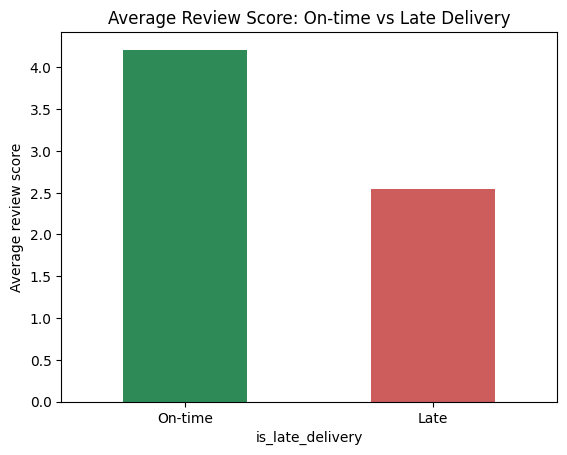

In [36]:
# Bar chart: average review score, on-time vs late
avg_by_late = df_analysis.groupby('is_late_delivery')['review_score'].mean()
print(avg_by_late)

avg_by_late.plot(kind='bar', color=['seagreen', 'indianred'])
plt.xticks([0, 1], ['On-time', 'Late'], rotation=0)
plt.ylabel('Average review score')
plt.title('Average Review Score: On-time vs Late Delivery')
plt.show()

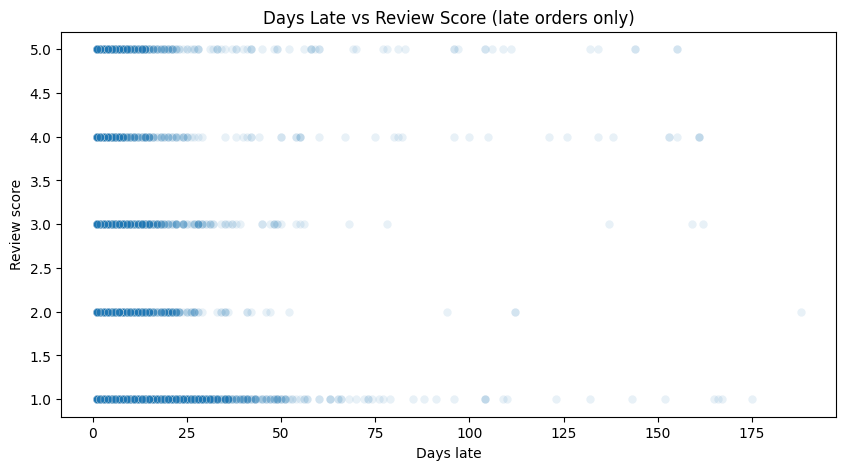

In [37]:
# A finer view: review score for each number of days late
# (only looking at orders that were actually late, i.e. delay > 0)
late_orders = df_analysis[df_analysis['delivery_delay_days'] > 0]

plt.figure(figsize=(10,5))
sns.scatterplot(data=late_orders, x='delivery_delay_days', y='review_score', alpha=0.1)
plt.title('Days Late vs Review Score (late orders only)')
plt.xlabel('Days late')
plt.ylabel('Review score')
plt.show()

order_value_bucket
1. Under 50    4.077643
2. 50-100      4.059951
3. 100-200     4.105899
4. 200-500     4.106983
5. 500+        4.100097
Name: review_score, dtype: float64


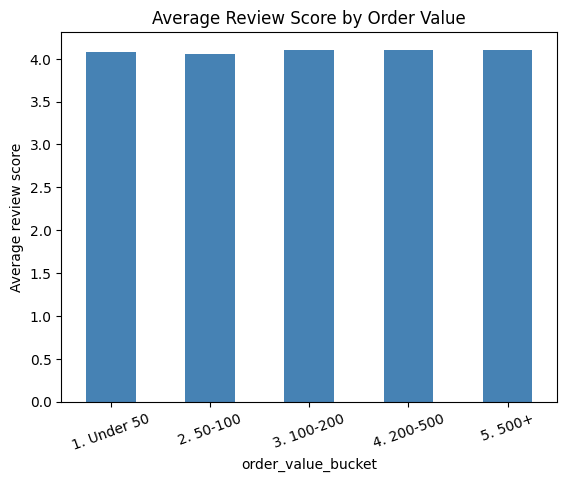

In [38]:
# Group order value into simple buckets
def value_bucket(price):
    if price < 50:
        return '1. Under 50'
    elif price < 100:
        return '2. 50-100'
    elif price < 200:
        return '3. 100-200'
    elif price < 500:
        return '4. 200-500'
    else:
        return '5. 500+'

df_analysis['order_value_bucket'] = df_analysis['price'].apply(value_bucket)

avg_by_value = df_analysis.groupby('order_value_bucket')['review_score'].mean()
print(avg_by_value)

avg_by_value.plot(kind='bar', color='steelblue')
plt.ylabel('Average review score')
plt.title('Average Review Score by Order Value')
plt.xticks(rotation=20)
plt.show()

freight_bucket
1. Under 10%    4.138297
2. 10-30%       4.110238
3. 30-50%       4.037482
4. 50-100%      4.035997
5. Over 100%    3.931202
Name: review_score, dtype: float64


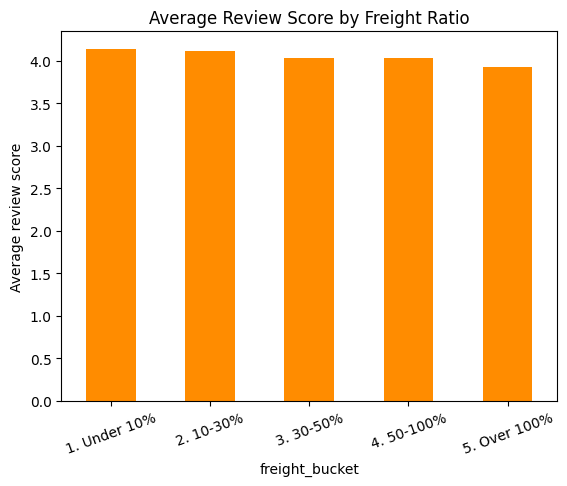

In [39]:
# Freight ratio can have extreme values, so we cap it at the 99th percentile just for the chart
cutoff = df_analysis['freight_ratio'].quantile(0.99)
freight_data = df_analysis[df_analysis['freight_ratio'] <= cutoff]

def freight_bucket(ratio):
    if ratio < 0.1:
        return '1. Under 10%'
    elif ratio < 0.3:
        return '2. 10-30%'
    elif ratio < 0.5:
        return '3. 30-50%'
    elif ratio < 1.0:
        return '4. 50-100%'
    else:
        return '5. Over 100%'

freight_data['freight_bucket'] = freight_data['freight_ratio'].apply(freight_bucket)

avg_by_freight = freight_data.groupby('freight_bucket')['review_score'].mean()
print(avg_by_freight)

avg_by_freight.plot(kind='bar', color='darkorange')
plt.ylabel('Average review score')
plt.title('Average Review Score by Freight Ratio')
plt.xticks(rotation=20)
plt.show()

        product_category_name_english  avg_review_score  num_orders
23                diapers_and_hygiene          3.378378          37
57                   office_furniture          3.516324        1654
34                    fixed_telephony          3.757937         252
30              fashion_male_clothing          3.758065         124
58                     party_supplies          3.833333          42
4                               audio          3.835196         358
47                       home_confort          3.861827         427
41  furniture_mattress_and_upholstery          3.891892          37
7                      bed_bath_table          3.924845       10831
27             fashio_female_clothing          3.933333          45


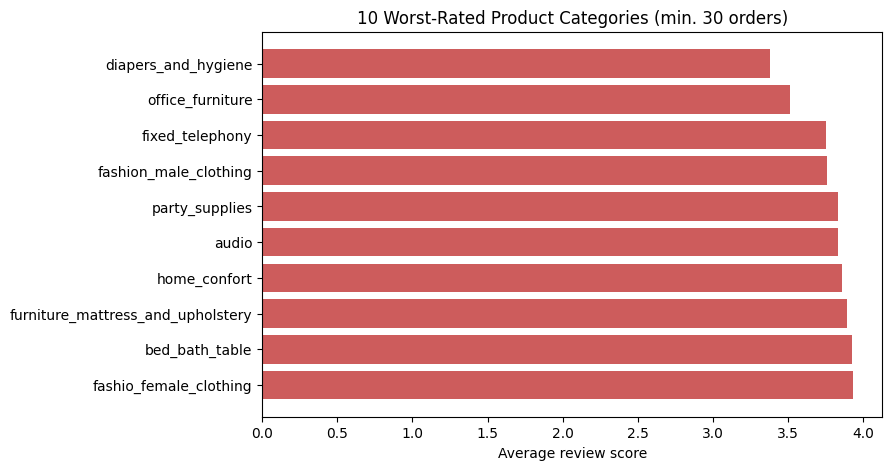

In [40]:
category_stats = df_analysis.groupby('product_category_name_english').agg(
    avg_review_score=('review_score', 'mean'),
    num_orders=('order_id', 'count')
).reset_index()

# Only look at categories with enough orders to be meaningful
category_stats = category_stats[category_stats['num_orders'] >= 30]

# Worst 10 categories
worst_categories = category_stats.sort_values('avg_review_score').head(10)
print(worst_categories)

plt.figure(figsize=(8,5))
plt.barh(worst_categories['product_category_name_english'], worst_categories['avg_review_score'], color='indianred')
plt.xlabel('Average review score')
plt.title('10 Worst-Rated Product Categories (min. 30 orders)')
plt.gca().invert_yaxis()
plt.show()

            product_category_name_english  avg_review_score  num_orders
8                  books_general_interest          4.512195         533
9                          books_imported          4.508772          57
22                costruction_tools_tools          4.444444          99
66  small_appliances_home_oven_and_coffee          4.438356          73
35                                flowers          4.419355          31
10                        books_technical          4.389313         262
37                             food_drink          4.364312         269
53                    luggage_accessories          4.352283        1073
31                          fashion_shoes          4.300395         253
13                             cine_photo          4.285714          70


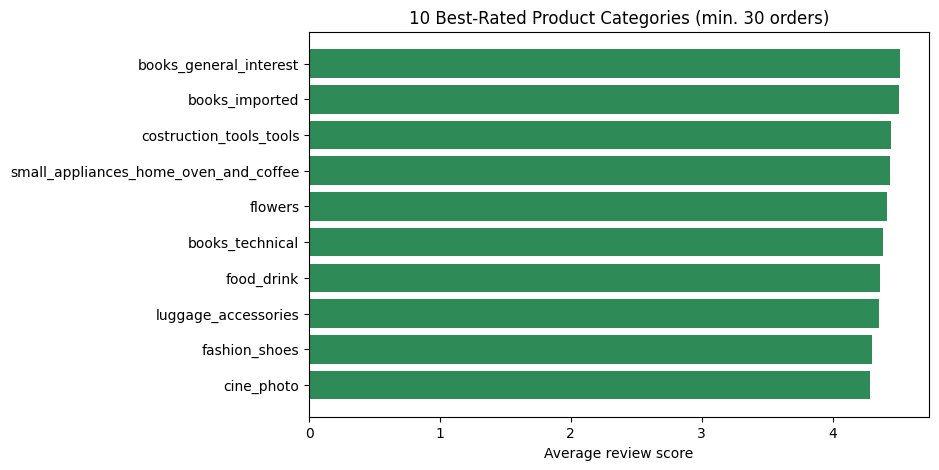

In [41]:
# Best 10 categories, for comparison
best_categories = category_stats.sort_values('avg_review_score', ascending=False).head(10)
print(best_categories)

plt.figure(figsize=(8,5))
plt.barh(best_categories['product_category_name_english'], best_categories['avg_review_score'], color='seagreen')
plt.xlabel('Average review score')
plt.title('10 Best-Rated Product Categories (min. 30 orders)')
plt.gca().invert_yaxis()
plt.show()

#  Seller performance → Customer satisfaction   
Are there sellers who consistently deliver a bad experience?

In [42]:
seller_stats = df_analysis.groupby('seller_id').agg(
    avg_review_score=('review_score', 'mean'),
    late_rate=('is_late_delivery', 'mean'),
    num_orders=('order_id', 'count'),
    revenue=('price', 'sum')
).reset_index()

# Only sellers with a reasonable number of orders
seller_stats = seller_stats[seller_stats['num_orders'] >= 20]

print("Number of sellers with 20+ orders:", seller_stats.shape[0])
seller_stats.sort_values('avg_review_score').head(10)

Number of sellers with 20+ orders: 878


,seller_id,avg_review_score,late_rate,num_orders,revenue
323,1ca7077d890b907f89be8c954a02686a,2.269841,0.190476,126,12324.64
1090,5bc55dbe2f12b6af6d83ed46023e0dc8,2.333333,0.190476,21,2992.10
450,2709af9587499e95e803a6498a5a56e9,2.600000,0.511111,45,1081.56
2157,bb135baca94c82fcb731335ad5b04a03,2.657895,0.000000,38,1049.80
2616,e250d617a0ad591ba9bd663e584a895d,2.800000,0.000000,20,904.12
539,2eb70248d66e0e3ef83659f71b244378,2.804124,0.139175,194,37624.95
1208,66fd84ee7528c0c0de85d0f44a73d5ab,2.904762,0.047619,21,1438.11
1137,602044f2c16190c2c6e45eb35c2e21cb,2.962963,0.222222,54,3491.67
1775,972d0f9cf61b499a4812cf0bfa3ad3c4,2.964286,0.119048,84,7748.79
1924,a49928bcdf77c55c6d6e05e09a9b4ca5,2.971154,0.250000,104,8646.90


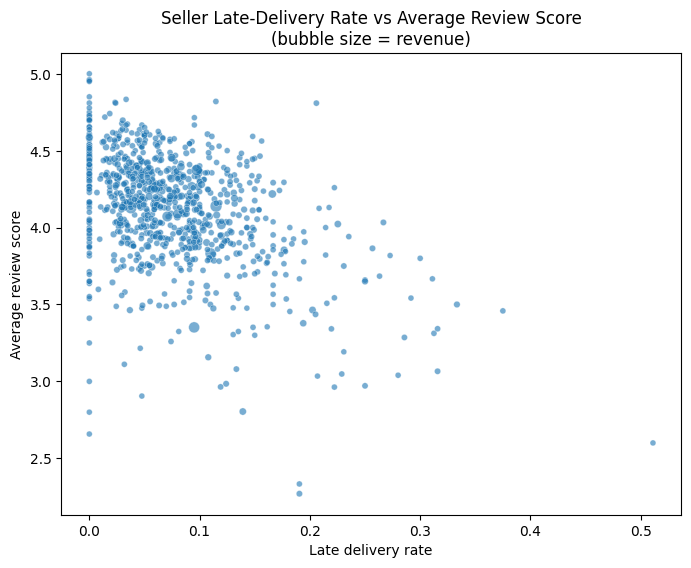

In [43]:
# Scatter plot: does a higher late-delivery rate line up with a lower review score?
plt.figure(figsize=(8,6))
sns.scatterplot(data=seller_stats, x='late_rate', y='avg_review_score', size='revenue', alpha=0.6, legend=False)
plt.xlabel('Late delivery rate')
plt.ylabel('Average review score')
plt.title('Seller Late-Delivery Rate vs Average Review Score\n(bubble size = revenue)')
plt.show()

In [44]:
# The "priority problem" list: high revenue, but low review score
priority_problem_sellers = seller_stats[
    (seller_stats['revenue'] >= seller_stats['revenue'].median()) &
    (seller_stats['avg_review_score'] < 3.5)
].sort_values('revenue', ascending=False)

print("Number of high-revenue, low-rating sellers:", priority_problem_sellers.shape[0])
priority_problem_sellers.head(10)

Number of high-revenue, low-rating sellers: 18


,seller_id,avg_review_score,late_rate,num_orders,revenue
1478,7c67e1448b00f6e969d365cea6b010ab,3.351151,0.095026,1347,185170.23
1334,712e6ed8aa4aa1fa65dab41fed5737e4,3.464286,0.202381,84,38796.00
539,2eb70248d66e0e3ef83659f71b244378,2.804124,0.139175,194,37624.95
1602,88460e8ebdecbfecb5f9601833981930,3.377926,0.193980,299,31244.15
1332,710e3548e02bc1d2831dfc4f1b5b14d4,3.463235,0.036765,136,22259.26
1612,897060da8b9a21f655304d50fd935913,3.474328,0.112469,409,21654.91
1563,8444e55c1f13cd5c179851e5ca5ebd00,3.156863,0.107843,102,21480.96
1679,8e6d7754bc7e0f22c96d255ebda59eba,2.984496,0.124031,129,14107.38
323,1ca7077d890b907f89be8c954a02686a,2.269841,0.190476,126,12324.64
1958,a7f13822ceb966b076af67121f87b063,3.493976,0.048193,83,11840.72
